In [3]:
import os
from matplotlib import pyplot as plt
import numpy as np
import sklearn
import sklearn.model_selection
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [4]:
# load class 1 data
data_path = 'data'

class1_data_path = os.path.join(data_path, 'class1')
class2_data_path = os.path.join(data_path, 'class2')

fix_size = 32_000


def load_file_data(file_data_path):
    
    if not os.path.isfile(file_data_path):
        return None
    
    data = np.array([])
    with open(file_data_path, 'r') as data_file:
        data = np.loadtxt(data_file, delimiter=' ')
        
    if data.shape[0] > fix_size:
        data = data[:fix_size, :]
    else:
        x = fix_size // data.shape[0]
        for i in range(x):
            data = np.concatenate((data, data), axis=0)

    data = data[:fix_size]
    return data


def load_data(folder_data_path):

    result_data = np.array([])
    for data_file_name in os.listdir(folder_data_path):
        
        data_file_path = os.path.join(folder_data_path, data_file_name)
        data = load_file_data(data_file_path)
        result_data = np.append(result_data, data)

    x = len(result_data) // fix_size
    result_data = result_data.reshape((x, fix_size))
    return result_data

class1_data = load_data(class1_data_path)
class1_label = np.ones((class1_data.shape[0]))

class2_data = load_data(class2_data_path)
class2_label = np.zeros((class2_data.shape[0]))

print(class1_data.shape)
print(class2_data.shape)
print(class1_label.shape)
print(class2_label.shape)


data = np.concatenate((class1_data, class2_data), axis=0)
print(data.shape)
label = np.concatenate((class1_label, class2_label), axis=0)
print(label.shape)

print(data[0])
print(label[0])


(38, 32000)
(73, 32000)
(38,)
(73,)
(111, 32000)
(111,)
[-10985. -11040. -11111. ...  -9586.  -9373.  -9426.]
1.0


In [5]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(data, label, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(88, 32000)
(23, 32000)


In [14]:

# Path: model.ipynb
from sklearn import svm
from sklearn.metrics import accuracy_score

clf = svm.SVC()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))


0.6521739130434783


0.6086956521739131


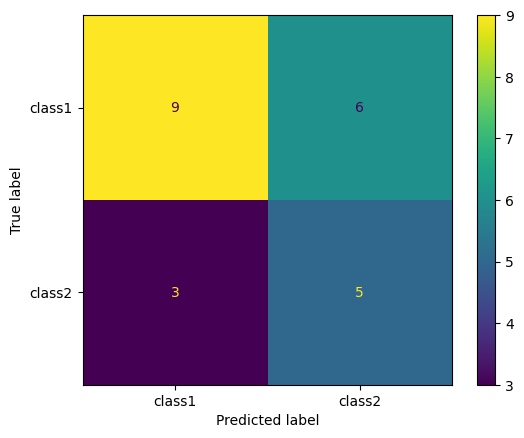

In [21]:
# apply linear kernel
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['class1', 'class2'])
disp.plot()




(88, 32000, 1)
(23, 32000, 1)
Epoch 1/15
3/3 [==============================] - 17s 5s/step - loss: 121300.8750 - accuracy: 0.4205 - val_loss: 0.6630 - val_accuracy: 0.6957
Epoch 2/15
3/3 [==============================] - 15s 5s/step - loss: 0.7999 - accuracy: 0.6705 - val_loss: 0.6929 - val_accuracy: 0.6522
Epoch 3/15
3/3 [==============================] - 16s 5s/step - loss: 0.6849 - accuracy: 0.6705 - val_loss: 0.6926 - val_accuracy: 0.6522
Epoch 4/15
3/3 [==============================] - 15s 5s/step - loss: 0.6924 - accuracy: 0.6591 - val_loss: 0.6923 - val_accuracy: 0.6522
Epoch 5/15
3/3 [==============================] - 15s 5s/step - loss: 0.6922 - accuracy: 0.6591 - val_loss: 0.6920 - val_accuracy: 0.6522
Epoch 6/15
3/3 [==============================] - 16s 5s/step - loss: 0.6919 - accuracy: 0.6591 - val_loss: 0.6918 - val_accuracy: 0.6522
Epoch 7/15
3/3 [==============================] - 15s 5s/step - loss: 0.6916 - accuracy: 0.6591 - val_loss: 0.6915 - val_accuracy: 0.6522

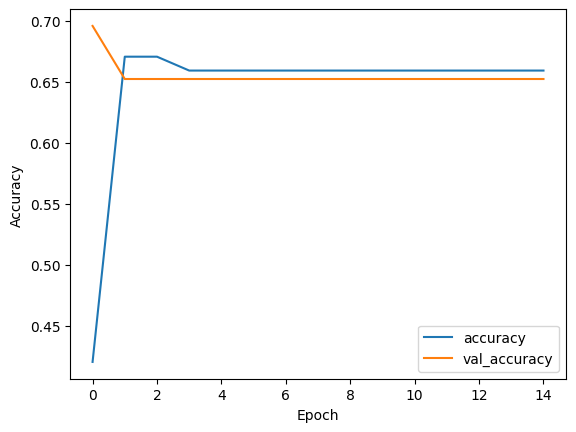

In [6]:
# Use CNN to train model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


# Path: model.ipynb
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(X_train.shape)
print(X_test.shape)

model = models.Sequential(
    [
        layers.Conv1D(256, 3, activation="relu", input_shape=(X_train.shape[1], 1)),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.5),
        layers.MaxPooling1D(2),
        layers.Conv1D(16, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()


In [7]:
model.summary()
model.save('model.h5')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 31998, 256)        1024      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 15999, 256)       0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 15997, 128)        98432     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 7998, 128)        0         
 1D)                                                             
                                                                 
 conv1d_2 (Conv1D)           (None, 7996, 64)          24640     
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 3998, 64)         0

1/1 [==============================] - 0s 266ms/step
0.7391304347826086


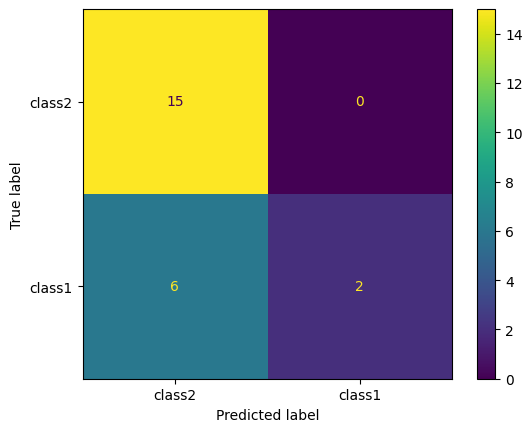

In [18]:
# draw confusion matrix
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['class2', 'class1'])
disp.plot()

0.6956521739130435


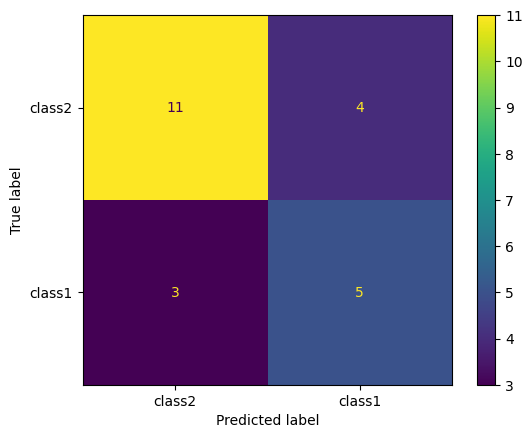

In [25]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=3)

# decrease dimension
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1]))

neigh.fit(X_train, y_train)

y_pred = neigh.predict(X_test)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['class2', 'class1'])
disp.plot()